In [ ]:
!pip install torchrl==0.12.0
!pip install gymnasium==1.2.3  # コンパチの都合でgymnasiumのバージョンを保つためにこの順番でインストールする

In [ ]:
import collections  # 経験バッファでなく環境で使ってる
import random

import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import tensordict
import torch
import torchrl
from torchrl.envs import GymWrapper
from tqdm.notebook import tqdm


print("gymnasium:", gym.__version__)
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)
print("tensordict:", tensordict.__version__)
print("pytorch:", torch.__version__)
print("torchrl:", torchrl.__version__)

gymnasium: 1.2.3
matplotlib: 3.10.0
numpy: 2.0.2
tensordict: 0.12.4
pytorch: 2.11.0+cpu
torchrl: 0.12.0


### 環境

In [ ]:
# gym.Envクラスを継承していて、gymのお作法(numpyで扱う、resetメソッドはstateとinfoを返す、stepメソッドはactionを引数でstateとrewardとterminatedとtruncatedとinfoを返す)になっていれば、
# 自作の環境クラスでもtorchrl.envのGymWrapperで包める
class MyInventoryEnv(gym.Env):
    def __init__(self, initial_inventory, max_step, lead_time):
        super().__init__()
        # ステップ数をカウントするため
        self.current_step = 0
        # 1エピソードの最大ステップ数
        self.max_step = max_step
        # 発注から納品までのリードタイム
        self.lead_time = lead_time
        # 納品待ち数を保存するキュー # 初期値は[0, 0]とする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # 状態の初期値を定義して、状態を定義する
        self.initial_state = np.array([initial_inventory]+list(self.delivery_queue),
                                      dtype=np.float32)
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # モデルがlearnやpredictメソッドの時に扱う行動(変数名はself.action_spaceがお作法)を定義
        self.action_space = gym.spaces.Discrete(n=11,  # 発注量は0から11個の離散値で0～10の行動となる # array形状は( )でint扱いになる
                                                seed=42,
                                                start=0,
                                                dtype=np.int32)
        # モデルがlearnやpredictメソッドの時に扱う状態(変数名はself.observation_spaceがお作法)を定義
        self.observation_space = gym.spaces.Box(low=0,  # 在庫数と納品待ち数(翌日と翌々日)として0～50の値で、array形状を(3, )とする
                                                high=50,
                                                shape=(1+self.lead_time, ),
                                                dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # 状態を初期状態にする
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # キューを初期値にする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # お作法としてinfo用の変数を作成する
        info = {}
        # ステップ数もリセットする
        self.current_step = 0
        # 初期状態とinfoを戻す
        return self.state, info

    def step(self, action):  # gymのお作法としてstep関数の引数はactionのみとする
        # ステップ数を+1する
        self.current_step = self.current_step + 1
        # 前々日に発注した数を納品する(キューの前から1つ取り出す)
        arrived_item = self.delivery_queue.popleft()
        # 需要は期待値が3のポアソン分布からサンプリングする
        demand = np.random.poisson(lam=3,
                                   size=(1, ))
        # サンプリングした需要と、納品数を踏まえて、在庫量を更新する
        inventory = np.clip(a=self.state[0] - demand[0] + arrived_item,
                            a_min=0,  # 在庫量はマイナスにはならない
                            a_max=50,  # 在庫量はself.observation_stateで定義したhigh=50を超えないようにするため
                            dtype=np.float32)
        # 行動(発注量)をキューの後ろに保存する
        self.delivery_queue.append(action)
        # 状態(在庫量と納品待ち数)を更新する
        self.state = np.array([inventory]+list(self.delivery_queue),
                              dtype=np.float32)
        # 在庫数15を基準として報酬を設定する # 在庫数15付近を保つように行動するようになると思う
        delta = abs(self.state[0] - 15)
        if 0 < delta < 5:
            reward = 1.0
        elif 5 <= delta < 10:
            reward = 0
        else:
            reward = - (delta * 0.1)
        # 発注を行う場合は発注コスト発生として報酬を減らす # ポアソン分布の期待値3の需要を見破られて発注を定期的に3にする事を防ぐ
        if action != 0:
            reward = reward - 0.5
        # 在庫量が0もしくは50になった場合は在庫管理が適切でなかったとしてterminatedをtrueにしてtruncatedはfalseにする
        if self.state[0] == 0 or self.state[0] == 50:
            terminated = True
            truncated = False  # ここでtruncatedをfalseにしてしまうのは、d3rlpyライブラリでは両方をtrueというのは許さない仕様のため
        else:  # 在庫量が0でない場合はterminatedをfalseにして、
            terminated = False
            # その時に、ステップ数が最大ステップ数の場合はtruncatedをtrueにする
            if self.current_step == self.max_step:
                truncated = True
            else:
                truncated = False
        # お作法としてinfoを用意する
        info = {}
        # 状態、報酬、terminated、truncated、infoの並びで戻す
        return self.state, reward, terminated, truncated, info

### 経験バッファ

In [ ]:
def create_torchrl_buffer(max_queue_size, seq_size, batch_size):
    # 経験バッファから所定の時系列サイズでバッチデータを切り出すサンプラー
    # https://docs.pytorch.org/rl/main/reference/generated/torchrl.data.replay_buffers.SliceSampler.html
    sampler = torchrl.data.replay_buffers.samplers.SliceSampler(slice_len=seq_size,  # 経験バッファから切り出す時の時系列数
                                                                end_key=("next", "done"))  # TensorDictのキーで["next"]の["done"]の値がTrueならばエピソード完了とみなす
    # 経験バッファ
    # https://docs.pytorch.org/rl/main/reference/generated/torchrl.data.TensorDictReplayBuffer.html
    # https://docs.pytorch.org/rl/main/reference/generated/torchrl.data.replay_buffers.LazyMemmapStorage.html
    buffer = torchrl.data.TensorDictReplayBuffer(storage=torchrl.data.LazyMemmapStorage(max_size=max_queue_size),  # どのような保存形式にするか # LazyMemmapStorageはメモリでなくディスクに実体を保存する
                                                 sampler=sampler,
                                                 batch_size=batch_size * seq_size)  # 経験バッファから切り出すデータ数 # つまり、バッチ数×時系列数の値にする
    return buffer

### 世界モデル
#####状態/行動から隠れ/潜在変数を得る

In [ ]:
class Encoder(torch.nn.Module):  # 状態を使って、状態特徴量を出力する
    def __init__(self, state_dim, state_feature_dim):
        super().__init__()
        self.state_feature_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=state_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=state_feature_dim)
        )

    def forward(self, state_tensor_data):
        state_feature = self.state_feature_layers(state_tensor_data)
        return state_feature

In [ ]:
class RssmRecurrent(torch.nn.Module):  # 潜在変数と行動と隠れを使って、隠れを出力する # 入力はt-1のもので、出力はtの隠れになる
    def __init__(self, latent_dim, action_dim, hidden_dim):
        super().__init__()
        self.layer_1 = torch.nn.GRUCell(input_size=latent_dim + action_dim,  # 1層だけのGRUとなり、
                                        hidden_size=hidden_dim)  # nn.GRUの出力は出力層からの隠れと全ての層からの隠れの2つだけれど、GRUCellは1層だけなので出力は1つの隠れのみ

    def forward(self, prev_latent_tensor_data, prev_action_onehot_tensor_data, prev_hidden_tensor_data):
        prev_latent_and_action = torch.cat(tensors=[prev_latent_tensor_data,
                                                    prev_action_onehot_tensor_data],
                                           dim=-1)
        hidden = self.layer_1(input=prev_latent_and_action,  # https://github.com/pytorch/pytorch/blob/v2.9.1/torch/nn/modules/rnn.py#L1721
                              hx=prev_hidden_tensor_data)
        return hidden

In [ ]:
def straight_through_estimator(logits_data):
    # 理解として、distsもdists.probsも確率分布であって、前者はクラスインスタンスで、後者はアトリビュート
    dists = torch.distributions.OneHotCategorical(logits=logits_data)  # バッチ個と時系列数個とnum_dist個の確率分布を持ち、それぞれの確率分布はnum_class個のカテゴリカル分布 # インスタンスなのでテンソル形状の表現は適切でない
    dists_probs = dists.probs  # 確率分布のカテゴリカル分布の値をsoftmax済みの確率値にしたもの # 逐次の場合の形状は(バッチ数, num_dist, num_class)で、一括の場合は(バッチ数, 時系列数, num_dist, num_class)
    dists_samples = dists.sample()  # 確率分布のカテゴリカル分布で1番高い確率値のclassを1、それ以外のclassは0のOneHotテンソルとして取得 # 逐次の場合の形状は(バッチ数, num_dist, num_class)で、一括の場合は(バッチ数, 時系列数, num_dist, num_class)
    ste = dists_samples + dists_probs - dists_probs.detach()  # 順伝播はサンプリング結果のdists_sample(OneHot)を用いて、逆伝播は微分可能なdists_probs(確率値)を用いるトリック
    batch_or_batch_seq_size = logits_data.shape[:-2]  # 逐次の場合は(バッチ数)を、一括の場合は(バッチ数, 時系列数)を取得する
    latent = ste.reshape(*batch_or_batch_seq_size, NUM_DISTS*NUM_CLASS)  # 逐次の場合の形状は(バッチ数, num_dist×num_class)で、一括の場合は(バッチ数, 時系列数, num_dist×num_class)
    return latent

In [ ]:
class PosteriorRssmStochastic(torch.nn.Module):  # 実データ(状態特徴量)と隠れを使って、STEにて事後の潜在変数と対数オッズを出力する
    def __init__(self, state_feature_dim, hidden_dim):
        super().__init__()
        self.num_dist = NUM_DISTS  # STE用に確率分布の数を指定
        self.num_class = NUM_CLASS  # STE用にクラスの数を指定
        self.logits_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=state_feature_dim + hidden_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=self.num_dist * self.num_class)
        )

    def forward(self, state_feature_tensor_data, hidden_tensor_data):
        state_feature_and_hidden_tensor_data = torch.cat(tensors=[state_feature_tensor_data,
                                                                  hidden_tensor_data],
                                                         dim=-1)  # 逐次の場合の形状は(バッチ数, state特徴量＋隠れの次元数)で、一括の場合は(バッチ数, 時系列数, state特徴量＋隠れの次元数)
        out_logits_layers = self.logits_layers(state_feature_and_hidden_tensor_data)  # 逐次の場合の形状は(バッチ数, num_dist×num_class)で、一括の場合は(バッチ数, 時系列数, num_dist×num_class)
        batch_or_batch_seq_size = out_logits_layers.shape[:-1]  # 逐次の場合は(バッチ数)を、一括の場合は(バッチ数, 時系列数)を取得する
        out_logits_layers_revised = out_logits_layers.reshape(*batch_or_batch_seq_size, self.num_dist, self.num_class)  # 逐次の場合の形状は(バッチ数, num_dist, num_class)で、一括の場合は(バッチ数, 時系列数, num_dist, num_class)
        latent = straight_through_estimator(logits_data=out_logits_layers_revised)
        return latent, out_logits_layers_revised  # straight through estimatorでのdistsはインスタンスなのでtensordictに保存できないため、logitsを返してKL lossを算出する際にlogitsをdistsに改めて変換する

In [ ]:
class PriorRssmStochastic(torch.nn.Module):  # 隠れだけを使って、STEにて事前の潜在変数と対数オッズを出力する
    def __init__(self, hidden_dim):
        super().__init__()
        self.num_dist = NUM_DISTS  # STE用に確率分布の数を指定
        self.num_class = NUM_CLASS  # STE用にクラスの数を指定
        self.logits_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=hidden_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=self.num_dist * self.num_class)
        )

    def forward(self, hidden_tensor_data):
        out_logits_layers = self.logits_layers(hidden_tensor_data)  # 逐次の場合の形状は(バッチ数, num_dist×num_class)で、一括の場合は(バッチ数, 時系列数, num_dist×num_class)
        batch_or_batch_seq_size = out_logits_layers.shape[:-1]  # 逐次の場合は(バッチ数)を、一括の場合は(バッチ数, 時系列数)を取得する
        out_logits_layers_revised = out_logits_layers.reshape(*batch_or_batch_seq_size, self.num_dist, self.num_class)  # 逐次の場合の形状は(バッチ数, num_dist, num_class)で、一括の場合は(バッチ数, 時系列数, num_dist, num_class)
        latent = straight_through_estimator(logits_data=out_logits_layers_revised)
        return latent, out_logits_layers_revised  # straight through estimatorでのdistsはインスタンスなのでtensordictに保存できないため、logitsを返してKL lossを算出する際にlogitsをdistsに改めて変換する

In [ ]:
class Decoder(torch.nn.Module):  # 潜在変数と隠れを使って、状態と報酬と完了フラグを出力する
    def __init__(self, latent_dim, hidden_dim, state_dim):
        super().__init__()
        self.state_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim + hidden_dim,
                            out_features=128),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128,
                            out_features=state_dim)
        )
        self.reward_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim + hidden_dim,
                            out_features=128),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128,
                            out_features=1)
        )
        self.done_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim + hidden_dim,
                            out_features=1),
            torch.nn.Sigmoid()
        )

    def forward(self, latent_tensor_data, hidden_tensor_data):
        latent_and_hidden = torch.cat(tensors=[latent_tensor_data,
                                               hidden_tensor_data],
                                      dim=-1)
        state = self.state_layers(latent_and_hidden)  # stateはencoderの入力のstateの再構成を狙ったものになる
        reward = self.reward_layers(latent_and_hidden)  # stateの再構成が出来てるならばrewardも適切なものになる想定
        done = self.done_layers(latent_and_hidden)  # ※sigmoidをかませる。この後の損失計算で用いる際は確率扱いにしているため
        return state, reward, done

In [ ]:
class MyTorchRLWorldModel(torch.nn.Module):  # イメージとしてはrecurrentでt-1のデータを使ってtの隠れを得て、そこからdecoderでtのデータを出力して、実データのtとの損失値で学習する
    def __init__(self, latent_dim, action_dim, hidden_dim, state_dim, state_feature_dim):
        super().__init__()
        self.action_dim = action_dim
        self.encoder = Encoder(state_dim=state_dim,
                               state_feature_dim=state_feature_dim)
        self.rssm_recurrent = RssmRecurrent(latent_dim=latent_dim,
                                            action_dim=action_dim,
                                            hidden_dim=hidden_dim)
        self.posterior_rssm_stochastic = PosteriorRssmStochastic(state_feature_dim=state_feature_dim,
                                                                 hidden_dim=hidden_dim)
        self.prior_rssm_stochastic = PriorRssmStochastic(hidden_dim=hidden_dim)
        self.decoder = Decoder(latent_dim=latent_dim,
                               hidden_dim=hidden_dim,
                               state_dim=state_dim)

    def forward(self, batch_tensordict):
        # 経験バッファの実データから状態と行動を取得
        state_datas = batch_tensordict["observation"]  # 形状は(バッチ数, 時系列数, 状態の次元数)
        action_datas = batch_tensordict["action"]  # 形状は(バッチ数, 時系列数, 1(スカラー値))
        action_onehot_datas = batch_tensordict["action_onehot"]  # 形状は(バッチ数, 時系列数, 行動の次元数)
        # t=0の時のt-1の行動と潜在変数と隠れをゼロ行列として作成
        prev_action_data = torch.zeros(size=(BATCH_SIZE, 1),  # 行動はスカラー値なので形状は(バッチ数, 1)にする
                                       dtype=torch.int64,  # one_hotメソッドの入力はLongTensorの必要があるため
                                       device=DEVICE)
        # https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.one_hot.html
        prev_action_onehot_data = torch.nn.functional.one_hot(prev_action_data,  # 形状はone_hotメソッドの仕様で(バッチ数, 1, action_dim)になるので、
                                                              num_classes=self.action_dim).squeeze(dim=1)  # squeezeメソッドで形状を(バッチ数, action_dim)にする
        prev_latent_data = torch.zeros(size=(BATCH_SIZE, LATENT_DIM),
                                       dtype=torch.float32,
                                       device=DEVICE)
        prev_hidden_data = torch.zeros(size=(BATCH_SIZE, HIDDEN_DIM),
                                       dtype=torch.float32,
                                       device=DEVICE)
        # 世界モデル(RSSM recurrent)からの出力を保存するリスト
        hidden_data_list = []
        # 世界モデル(posterior RSSM stochastic)からの出力を保存するリスト
        posterior_latent_data_list = []
        posterior_logits_data_list = []
        # 世界モデル(decoder)からの出力を保存するリスト
        predicted_state_data_list = []
        predicted_reward_data_list = []
        predicted_done_data_list = []
        # 世界モデル(prior RSSM stochastic)からの出力を保存するリスト
        prior_latent_data_list = []
        prior_logits_data_list = []
        for t in range(SEQ_SIZE):  # Dreamer v2は逐次処理の世界モデルのため
            # RSSM recurrentにt-1の潜在変数と行動と隠れを入力して、tの隠れを得る
            hidden_data = self.rssm_recurrent(prev_latent_tensor_data=prev_latent_data,  # 形状は(バッチ数, 隠れの次元数)
                                              prev_action_onehot_tensor_data=prev_action_onehot_data,
                                              prev_hidden_tensor_data=prev_hidden_data)
            # encoderに入力に使う実データのtの状態を経験バッファから取得する
            state_data = state_datas[:, t, :]  # 形状は(バッチ数, 状態の次元数)
            # encoderにtの状態を入力して、tの状態特徴量を得る
            state_feature_data = self.encoder(state_tensor_data=state_data)  # 形状は(バッチ数, 状態特徴量の次元数)
            # posterior RSSM stochasticにtの状態特徴量と隠れを入力して、tの事後潜在変数と事後対数オッズを得る
            posterior_latent_data, posterior_logits_data = self.posterior_rssm_stochastic(state_feature_tensor_data=state_feature_data,  # 形状は(バッチ数, 潜在変数の次元数)と(バッチ数, num_dist, num_class)
                                                                                          hidden_tensor_data=hidden_data)
            # decoderにtの事後潜在変数と隠れを入力して、tの状態と報酬と完了フラグを得る
            predicted_state_data, predicted_reward_data, predicted_done_data = self.decoder(latent_tensor_data=posterior_latent_data,  # 形状は(バッチ数, 状態の次元数)と(バッチ数, 行動の次元数)と(バッチ数, 完了フラグの次元数)
                                                                                            hidden_tensor_data=hidden_data)
            # prior RSSM stochasticにtの隠れを入力して、tの事前潜在変数と事前対数オッズを得る
            prior_latent_data, prior_logits_data = self.prior_rssm_stochastic(hidden_tensor_data=hidden_data)  # 形状は(バッチ数, 潜在変数の次元数)と(バッチ数, num_dist, num_class)
            # 得られたデータをリストに保存する
            hidden_data_list.append(hidden_data)
            posterior_latent_data_list.append(posterior_latent_data)
            posterior_logits_data_list.append(posterior_logits_data)
            predicted_state_data_list.append(predicted_state_data)
            predicted_reward_data_list.append(predicted_reward_data)
            predicted_done_data_list.append(predicted_done_data)
            prior_latent_data_list.append(prior_latent_data)
            prior_logits_data_list.append(prior_logits_data)
            # 次の推論に向けて、潜在変数と隠れをt-1扱いにする
            prev_latent_data = posterior_latent_data
            prev_hidden_data = hidden_data
            # 次に推論に向けて、実データのtの行動を経験バッファから取得して、t-1として用いる
            prev_action_data = action_datas[:, t, :]  # 形状は(バッチ数, 行動の次元数)
            prev_action_onehot_data = action_onehot_datas[:, t, :]
        # リストに保存したデータを時系列を踏まえてstackして、損失計算で使うためにbatch_tensordictに保存して戻り値で返す
        batch_tensordict["hidden"] = torch.stack(tensors=hidden_data_list,
                                                 dim=1)  # 形状は(バッチ数, 時系列数, 隠れの次元数)
        batch_tensordict["posterior_latent"] = torch.stack(tensors=posterior_latent_data_list,
                                                           dim=1)  # 形状は(バッチ数, 時系列数, 潜在変数の次元数)
        batch_tensordict["posterior_logits"] = torch.stack(tensors=posterior_logits_data_list,
                                                           dim=1)  # 形状は(バッチ数, 時系列数, num_dist, num_class)
        batch_tensordict["predicted_state"] = torch.stack(tensors=predicted_state_data_list,
                                                          dim=1)  # 形状は(バッチ数, 時系列数, 状態の次元数)
        batch_tensordict["predicted_reward"] = torch.stack(tensors=predicted_reward_data_list,
                                                           dim=1)  # 形状は(バッチ数, 時系列数, 報酬の次元数)
        batch_tensordict["predicted_done"] = torch.stack(tensors=predicted_done_data_list,
                                                         dim=1)  # 形状は(バッチ数, 時系列数, 完了フラグの次元数)
        batch_tensordict["prior_latent"] = torch.stack(tensors=prior_latent_data_list,
                                                       dim=1)  # 形状は(バッチ数, 時系列数, 潜在変数の次元数)
        batch_tensordict["prior_logits"] = torch.stack(tensors=prior_logits_data_list,
                                                       dim=1)  # 形状は(バッチ数, 時系列数, num_dist, num_class)
        return batch_tensordict

### 世界モデル学習

In [ ]:
def calculate_kl_loss(posterior_logits, prior_logits, kl_balancing=0.8, kl_threshold=1.0, kl_loss_weight=1.0):
    # straight through estimatorの時と同じようにlogitsをdistsに変換する
    posterior_dists = torch.distributions.OneHotCategorical(logits=posterior_logits)  # distsの形状のイメージは(バッチ数, 時系列数, num_dist, num_class) ※正確ではない
    prior_dists = torch.distributions.OneHotCategorical(logits=prior_logits)
    # posteriorとpriorのそれぞれでnum_dist個の確率分布を1個の確率分布とする
    posterior_dist = torch.distributions.Independent(base_distribution=posterior_dists,
                                                     reinterpreted_batch_ndims=1)  # distの形状のイメージは(バッチ数, 時系列数, num_class) ※正確ではない
    prior_dist = torch.distributions.Independent(base_distribution=prior_dists,
                                                 reinterpreted_batch_ndims=1)
    # KLダイバージェンス値を求めるにあたり、基準扱いとなるposteriorとpriorの確率分布を勾配を外した形で作る
    posterior_prob_dists_detach = torch.distributions.OneHotCategorical(logits=posterior_logits.detach())
    posterior_prob_dist_detach = torch.distributions.Independent(base_distribution=posterior_prob_dists_detach,
                                                                 reinterpreted_batch_ndims=1)
    prior_prob_dists_detach = torch.distributions.OneHotCategorical(logits=prior_logits.detach())
    prior_prob_dist_detach = torch.distributions.Independent(base_distribution=prior_prob_dists_detach,
                                                             reinterpreted_batch_ndims=1)
    # Left Hand Side(基準はposteriorの方)のKLダイバージェンス値
    kl_lhs = torch.distributions.kl.kl_divergence(p=posterior_prob_dist_detach,  # 確率変数はnum_class個の確率分布間のKLダイバージェンス値は一意の値になるので、形状は(バッチ数, 時系列数)
                                                  q=prior_dist)
    # Right Hand Side(基準はpriorの方)のKLダイバージェンス値
    kl_rhs = torch.distributions.kl.kl_divergence(p=posterior_dist,
                                                  q=prior_prob_dist_detach)
    # LHSを重くする形でKLダイバージェンス値を合算する(posteriorの方が実データの分布なのでLHSを重くする)
    kl_sum = kl_balancing * kl_lhs + (1 - kl_balancing) * kl_rhs
    # 閾値以下だった場合は閾値の方を扱う(KLダイバージェンス値を0に持って行かせないため)
    kl_sum = torch.maximum(input=kl_sum,
                           other=torch.tensor(data=kl_threshold).to(DEVICE))
    # 損失値としてどの程度KLダイバージェンス値を用いるかの観点で重みを掛ける
    kl_loss = kl_loss_weight * kl_sum
    return kl_loss.mean()  # 必ずスカラー値とするためにmean()を付ける

In [ ]:
def train_my_torchrl_world_model(world_model, world_model_optimizer, batch_tensordict):
    # 世界モデルにて推論
    batch_tensordict = world_model(batch_tensordict=batch_tensordict)
    # 世界モデルが推論したtの状態、報酬、完了フラグに対する実データのtの状態、報酬、完了フラグとの損失値を算出
    state_loss = torch.nn.functional.mse_loss(input=batch_tensordict["predicted_state"],  # 推論したtの状態
                                              target=batch_tensordict["observation"],  # 実データのtの状態
                                              reduction="mean")
    reward_loss = torch.nn.functional.mse_loss(input=batch_tensordict["predicted_reward"],  # 推論したtの報酬
                                               target=batch_tensordict["next", "reward"],  # 実データのtの報酬 # TorchRLの仕様でnextの方になる
                                               reduction="mean")
    done_loss = torch.nn.functional.binary_cross_entropy(input=batch_tensordict["predicted_done"],  # 推論したtの完了フラグ
                                                         target=batch_tensordict["next", "done"].to(torch.float32),  # 実データのtの完了フラグ # TorchRLの仕様でnextの方になる
                                                         reduction="mean")
    # 世界モデルが推論した事後確率分布と事前確率分布で損失値を算出
    kl_dists_loss = calculate_kl_loss(posterior_logits=batch_tensordict["posterior_logits"],  # 形状は(バッチ数, 時系列数, num_dist, num_class)
                                      prior_logits=batch_tensordict["prior_logits"])  # 形状は(バッチ数, 時系列数, num_dist, num_class)
    # 損失値を合計
    world_model_loss = state_loss + reward_loss + done_loss + kl_dists_loss
    # 誤差逆伝播と勾配降下法
    world_model_optimizer.zero_grad()
    world_model_loss.backward()
    world_model_optimizer.step()
    return batch_tensordict, world_model_loss.item()  # グラフ用に損失値も返しとく

### Actor-Critic

In [ ]:
class MyDreamerActor(torch.nn.Module):  # 隠れと潜在変数を使って、離散的な行動を出力する
    def __init__(self, hidden_dim, latent_dim, actor_units, action_dim):
        super().__init__()
        self.action_dim = action_dim  # one_hotメソッドの引数num_classesで使うため
        self.actor_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=hidden_dim + latent_dim,
                            out_features=actor_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=actor_units,
                            out_features=actor_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=actor_units,
                            out_features=action_dim)
        )

    def forward(self, hidden_tensor_data, latent_tensor_data):
        hidden_and_latent = torch.cat(tensors=[hidden_tensor_data,
                                               latent_tensor_data],
                                      dim=-1)
        out_actor_layers = self.actor_layers(hidden_and_latent)
        out_actor_layers_distribution = torch.distributions.Categorical(logits=out_actor_layers)
        if self.training:
            discrete_action = out_actor_layers_distribution.sample()
        else:
            discrete_action = out_actor_layers.argmax(dim=-1)
        # https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.one_hot.html
        discrete_action_onehot = torch.nn.functional.one_hot(discrete_action,
                                                             num_classes=self.action_dim)
        # print(discrete_action.shape)  # 形状は(バッチ数, ) # 行動はスカラー値であって、torch.nn.Moduleの仕様で(バッチ数, 1)の行列でなく(バッチ数, )のベクトルになる
        # print(discrete_action_onehot.shape)  # 形状は(バッチ数, action_dim)
        return discrete_action, discrete_action_onehot

In [ ]:
class MyDreamerCritic(torch.nn.Module):  # 隠れと潜在変数を使って、状態価値を出力する
    def __init__(self, hidden_dim, latent_dim, critic_units):
        super().__init__()
        self.critic_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=hidden_dim + latent_dim,
                            out_features=critic_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=critic_units,
                            out_features=critic_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=critic_units,
                            out_features=1)
        )

    def forward(self, hidden_tensor_data, latent_tensor_data):
        hidden_and_latent = torch.cat(tensors=[hidden_tensor_data,
                                               latent_tensor_data],
                                      dim=-1)
        out_critic_layers = self.critic_layers(hidden_and_latent)
        return out_critic_layers

### Actor-Critic学習

In [ ]:
def get_imagined_reward_and_value(imagined_latent, imagined_hidden, world_model, critic):  # λ-returnを算出するために報酬と状態価値を取得する
    _, imagined_reward, _ = world_model.decoder(latent_tensor_data=imagined_latent,  # 形状は(バッチ数, horizon数, 1)
                                                hidden_tensor_data=imagined_hidden)
    imagined_value = critic(hidden_tensor_data=imagined_hidden,  # 形状は(バッチ数, horizon数, 1)
                            latent_tensor_data=imagined_latent)
    return imagined_reward, imagined_value

In [ ]:
def calculate_lambda_return(imagined_reward, imagined_value, gamma=0.99, lmbda=0.95):
    # lambda_returnはTD法とモンテカルロ法を合わせたようなもので、下記の式でゴール地点から遡って再帰的に算出していく
    # Gt = rt + γ((1 - λ) * Vt+1 + λ * Gt+1)
    # Gは収益、rは報酬、γは割引率、Vは状態価値、λはTD法とモンテカルロ法の重み
    # λを0にすると実質TD法になり、λを1にすると実質モンテカルロ法になる
    # コードを実装するポイントとして、式にVt+1やGt+1があるのでout of rangeにならないようにhorizon-1の範囲で算出する
    horizon = imagined_reward.shape[1]
    g_next = imagined_value[:, -1, :]  # ゴール地点でのGt+1は、ゴール地点の状態価値で代替する
    lambda_return_list = []
    for t in reversed(range(horizon-1)):
        r = imagined_reward[:, t, :]
        v_next = imagined_value[:, t+1, :]
        g = r + gamma * ((1.0 - lmbda) * v_next + lmbda * g_next)  # Gt = rt + γ((1 - λ) * Vt+1 + λ * Gt+1)
        lambda_return_list.append(g)
        g_next = g
    lambda_return_list.reverse()
    lambda_return_tensor = torch.stack(tensors=lambda_return_list,
                                       dim=1)
    return lambda_return_tensor

In [ ]:
def train_actor_and_critic(imagination_batch_tensordict, world_model, critic, actor_optimizer, critic_optimizer):
    # Actorの損失値を算出するにはCriticの出力も用いるため逆伝播でcriticも通るけれど、Actorの損失値でCriticを学習させたくないので一時的にCriticの勾配計算をfalseにして外す
    for param in critic.parameters():
        param.requires_grad_(requires_grad=False)
    # Actorの損失値用のλ-returnを算出するために、妄想で得たデータで報酬と状態価値を推論
    imagined_reward_for_actor_loss, imagined_value_for_actor_loss = get_imagined_reward_and_value(imagined_latent=imagination_batch_tensordict["imagined_latent"],  # 両方ともデータの形状は(バッチ数, horizon数, 1)
                                                                                                  imagined_hidden=imagination_batch_tensordict["imagined_hidden"],
                                                                                                  world_model=world_model,
                                                                                                  critic=critic)
    # Actorの損失値用にλ-returnを算出
    lambda_return_for_actor_loss = calculate_lambda_return(imagined_reward=imagined_reward_for_actor_loss,  # 形状は(バッチ数, horizon数-1, 1)
                                                           imagined_value=imagined_value_for_actor_loss)
    # Criticの損失値を算出する際の正解データ用にλ-returnをコピー(正解データ用なので勾配は外す)
    lambda_return_for_critic_target = lambda_return_for_actor_loss.clone().detach()  # 形状は(バッチ数, horizon数-1, 1)
    # Actorを学習
    actor_loss = - torch.mean(input=lambda_return_for_actor_loss,  # Actorの損失値(λ-returnの逆符号になる)
                              dtype=torch.float32)

    actor_optimizer.zero_grad()
    actor_loss.backward()
    actor_optimizer.step()
    # Criticの勾配計算をtrueにして元に戻す
    for param in critic.parameters():
        param.requires_grad_(requires_grad=True)
    # Criticの損失値を算出する際の推論データ用に、妄想で得たデータで状態価値を推論(報酬は使わない) # 先程推論した状態価値はActorの学習で勾配を使ってしまったので改めて推論する
    _, imagined_value_for_critic = get_imagined_reward_and_value(imagined_latent=imagination_batch_tensordict["imagined_latent"],  # 両方ともデータの形状は(バッチ数, horizon数, 1)
                                                                 imagined_hidden=imagination_batch_tensordict["imagined_hidden"],
                                                                 world_model=world_model,
                                                                 critic=critic)
    # Criticを学習
    critic_loss = torch.nn.functional.mse_loss(input=imagined_value_for_critic[:, :-1, :],  # 状態価値の時系列のゴール地点はt+1扱いになるので含めない # 形状は(バッチ数, horizon数-1, 1)
                                               target=lambda_return_for_critic_target,  # 正解データはλ-return
                                               reduction="mean")
    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()
    return actor_loss.item(), critic_loss.item()

### 妄想

In [ ]:
def torchrl_imagination(batch_tensordict, world_model, actor, horizon):
    # 妄想の最初のデータ用に、最新の時系列のデータの隠れと潜在変数を、t-1の隠れと潜在変数として用いる
    prev_hidden = batch_tensordict["hidden"][:, -1, :].detach()
    prev_latent = batch_tensordict["posterior_latent"][:, -1, :].detach()
    # データの保存用にリストを準備
    imagined_action_list = []
    imagined_action_onehot_list = []
    imagined_hidden_list = []
    imagined_latent_list = []
    # Actorと世界モデル(RSSM Recurrent/Prior RSSM Stochastic)で妄想して、妄想での行動と隠れと潜在変数を得る
    for _ in range(horizon):
        prev_action, prev_action_onehot = actor(hidden_tensor_data=prev_hidden,
                                                latent_tensor_data=prev_latent)
        imagined_action_list.append(prev_action)
        imagined_action_onehot_list.append(prev_action_onehot)
        hidden = world_model.rssm_recurrent(prev_latent_tensor_data=prev_latent,
                                            prev_action_onehot_tensor_data=prev_action_onehot,
                                            prev_hidden_tensor_data=prev_hidden)
        latent, _ = world_model.prior_rssm_stochastic(hidden_tensor_data=hidden)
        imagined_hidden_list.append(hidden)
        imagined_latent_list.append(latent)
        prev_hidden = hidden
        prev_latent = latent
    imagined_action_tensor = torch.stack(tensors=imagined_action_list,
                                         dim=1)
    imagined_action_onehot_tensor = torch.stack(tensors=imagined_action_onehot_list,
                                                dim=1)
    imagined_hidden_tensor = torch.stack(tensors=imagined_hidden_list,
                                         dim=1)
    imagined_latent_tensor = torch.stack(tensors=imagined_latent_list,
                                         dim=1)
    # https://docs.pytorch.org/tensordict/stable/reference/generated/tensordict.TensorDict.html
    imagined_tensordict = tensordict.TensorDict(source={"imagined_action": imagined_action_tensor,
                                                        "imagined_action_onehot": imagined_action_onehot_tensor,
                                                        "imagined_hidden": imagined_hidden_tensor.detach(),  # ActorやCriticの損失値の算出で用いるけれど、ActorやCriticの学習時の逆伝播で
                                                        "imagined_latent": imagined_latent_tensor.detach()},  # RSSM RecurrentやPrior RSSMに勾配を流して学習させたくないので、ここで勾配を外しとく
                                                batch_size=[BATCH_SIZE, horizon],
                                                device=DEVICE)
    return imagined_tensordict

### 実データ収集

In [ ]:
def collect_data_from_environment(env, world_model, actor, step, replay_buffer):
    for i in range(step):
        data_tensordict = env.reset()
        latent = torch.zeros(size=(1, LATENT_DIM),  # 形状のイメージは(バッチ数, 潜在変数の次元数)
                             dtype=torch.float32,
                             device=DEVICE)
        hidden = torch.zeros(size=(1, HIDDEN_DIM),  # 形状のイメージは(バッチ数, 隠れの次元数)
                             dtype=torch.float32,
                             device=DEVICE)
        action = torch.zeros(size=(1, 1),  # 形状のイメージは(バッチ数, 行動の次元数) # 行動はスカラー値にするので次元数は1
                             dtype=torch.int64,  # one_hotメソッドの入力はLongTensorの必要があるため
                             device=DEVICE)
        # https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.one_hot.html
        action_onehot = torch.nn.functional.one_hot(action,  # 形状はone_hotメソッドの仕様で(1, 1, action_dim)になるので、
                                                    num_classes=ACTION_DIM).squeeze(dim=1)  # squeezeメソッドで形状を(1, action_dim)にする
        while True:
            state = data_tensordict["observation"]
            state = state.unsqueeze(dim=0).to(DEVICE)  # モデル入力に向けてバッチ軸を追加
            with torch.no_grad():
                state_feature = world_model.encoder(state_tensor_data=state)
                hidden = world_model.rssm_recurrent(prev_latent_tensor_data=latent,
                                                    prev_action_onehot_tensor_data=action_onehot,
                                                    prev_hidden_tensor_data=hidden)
                latent, _ = world_model.posterior_rssm_stochastic(state_feature_tensor_data=state_feature,
                                                                  hidden_tensor_data=hidden)
                action, action_onehot = actor(hidden_tensor_data=hidden,
                                              latent_tensor_data=latent)
            data_tensordict["action"] = action
            data_tensordict["action_onehot"] = action_onehot.squeeze(dim=0)  # actorからの出力のonehotは(1, 11)行列なので、tensordictや経験バッファに保存するために(11, )ベクトルにする
            data_tensordict = env.step(data_tensordict)  # stepの結果がnextをキーとした値に入る # つまりt+1の値を得る
            replay_buffer.add(data_tensordict)
            if data_tensordict["next", "done"].item():
                break
            # https://docs.pytorch.org/rl/0.4/reference/generated/torchrl.envs.utils.step_mdp.html#step-mdp
            data_tensordict = torchrl.envs.utils.step_mdp(tensordict=data_tensordict)  # nextをキーとした値をnext無しのキーの値にする # つまりt+1の値をtの値にする
    return replay_buffer

### 推論

In [ ]:
def inference_timestep(env, world_model, actor):
    state_list = []
    action_list = []
    reward_list = []
    data_tensordict = env.reset()
    prev_latent = torch.zeros(size=(1, LATENT_DIM),  # 形状のイメージは(バッチ数, 潜在変数の次元数)
                              dtype=torch.float32,
                              device=DEVICE)
    prev_hidden = torch.zeros(size=(1, HIDDEN_DIM),  # 形状のイメージは(バッチ数, 隠れの次元数)
                              dtype=torch.float32,
                              device=DEVICE)
    prev_action = torch.zeros(size=(1, 1),  # 形状のイメージは(バッチ数, 行動の次元数) # 行動はスカラー値にするので次元数は1
                              dtype=torch.int64,  # one_hotメソッドの入力はLongTensorの必要があるため
                              device=DEVICE)
    # https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.one_hot.html
    prev_action_onehot = torch.nn.functional.one_hot(prev_action,  # 形状はone_hotメソッドの仕様で(1, 1, action_dim)になるので、
                                                     num_classes=ACTION_DIM).squeeze(dim=1)  # squeezeメソッドで形状を(1, action_dim)にする
    while True:
        state = data_tensordict["observation"]
        state = state.unsqueeze(dim=0).to(DEVICE)
        with torch.no_grad():
            hidden = world_model.rssm_recurrent(prev_latent_tensor_data=prev_latent,
                                                prev_action_onehot_tensor_data=prev_action_onehot,
                                                prev_hidden_tensor_data=prev_hidden)
            state_feature = world_model.encoder(state_tensor_data=state)
            latent, _ = world_model.posterior_rssm_stochastic(state_feature_tensor_data=state_feature,  # 推論では環境からstateを得られるのでposteriorで潜在変数を得る
                                                              hidden_tensor_data=hidden)
            action, action_onehot = actor(hidden_tensor_data=hidden,
                                          latent_tensor_data=latent)
        data_tensordict["action"] = action
        data_tensordict["action_onehot"] = action_onehot
        data_tensordict = env.step(data_tensordict)
        state_list.append(data_tensordict["observation"].cpu())  # 出力結果をグラフ化したりするためcpuに戻す
        action_list.append(data_tensordict["action"].cpu())  # 出力結果をグラフ化したりするためcpuに戻す
        reward_list.append(data_tensordict["next", "reward"].cpu())  # 出力結果をグラフ化したりするためcpuに戻す
        if data_tensordict["next", "done"].item():
            break
        data_tensordict = torchrl.envs.utils.step_mdp(tensordict=data_tensordict)
        prev_latent = latent
        prev_hidden = hidden
        prev_action = action
        prev_action_onehot = action_onehot
    return state_list, action_list, reward_list

### メイン処理

### メイン処理(準備)

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
SEQ_SIZE = 30
STATE_FEATURE_DIM = 200
HIDDEN_DIM = 400
ACTION_DIM = 11  # 0～10の離散値のため
ACTOR_UNITS = 256
CRITIC_UNITS = 256
NUM_DISTS = 32
NUM_CLASS = 32
LATENT_DIM = NUM_DISTS * NUM_CLASS
STEP_FOR_COLLECTEING_DATA = 50
LEARNING_EPOCH = 150
WORLD_MODEL_LEARNING_NUM = 3
ACTOR_CRITIC_LEARNING_NUM = 5

In [ ]:
# 環境を準備
my_base_env = MyInventoryEnv(initial_inventory=20,
                             max_step=31,
                             lead_time=2)
# これで普通にenv.reset()やenv.step()を使える
# 戻り値のデータ型はTensorDictという型で、特徴としてはネストされたキーをtd["next"]["done"]でなくtd[("next", "done")]の形でアクセス出来る
# 他にはdoneというデータが自動で付与される。これはterminatedやtruncatedがTrueの場合にTrueとなる
# https://docs.pytorch.org/rl/main/reference/generated/torchrl.envs.GymWrapper.html
my_env = GymWrapper(env=my_base_env,
                    categorical_action_encoding=True)  # 行動が離散値(continuous_action_flagをFalse)の場合に、Trueだと5や7のスカラーになって、Falseだと行動の数の次元のone-hotベクトルになる
# 状態の次元を環境から自動で取得する
state_dim = my_env.observation_spec["observation"].shape[-1]

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 世界モデルを準備
my_world_model = MyTorchRLWorldModel(latent_dim=LATENT_DIM,
                                     action_dim=ACTION_DIM,
                                     hidden_dim=HIDDEN_DIM,
                                     state_dim=state_dim,
                                     state_feature_dim=STATE_FEATURE_DIM).to(DEVICE)
my_world_model_optimizer = torch.optim.Adam(params=my_world_model.parameters(),
                                            lr=0.001)
# ActorとCriticを準備
my_actor = MyDreamerActor(hidden_dim=HIDDEN_DIM,
                          latent_dim=LATENT_DIM,
                          actor_units=ACTOR_UNITS,
                          action_dim=ACTION_DIM).to(DEVICE)
my_actor_optimizer = torch.optim.Adam(params=my_actor.parameters(),
                                      lr=0.001)
my_critic = MyDreamerCritic(hidden_dim=HIDDEN_DIM,
                            latent_dim=LATENT_DIM,
                            critic_units=CRITIC_UNITS).to(DEVICE)
my_critic_optimizer = torch.optim.Adam(params=my_critic.parameters(),
                                       lr=0.001)

In [ ]:
# 経験バッファを準備
my_replay_buffer = create_torchrl_buffer(max_queue_size=100000,
                                         seq_size=SEQ_SIZE,
                                         batch_size=BATCH_SIZE)

### メイン処理(学習)

In [ ]:
# 世界モデルとActor-Criticを学習
my_world_model.train()
my_actor.train()
my_critic.train()
my_world_model_average_loss_list = []
my_actor_average_loss_list = []
my_critic_average_loss_list = []
for epoch in tqdm(range(LEARNING_EPOCH)):
    # 実データを経験バッファへ収集
    my_replay_buffer = collect_data_from_environment(env=my_env,
                                                     world_model=my_world_model,
                                                     actor=my_actor,
                                                     step=STEP_FOR_COLLECTEING_DATA,
                                                     replay_buffer=my_replay_buffer)
    # 世界モデルを学習
    my_world_model_total_loss = 0
    for _ in range(WORLD_MODEL_LEARNING_NUM):
        # 経験バッファからサンプリング
        buffer_data_batch_tensordict = my_replay_buffer.sample().to(DEVICE)  # データの形状は(サンプリング数, それぞれのデータの次元数)
        # サンプリング数の軸をバッチ数と時系列数の軸に分ける
        reshaped_buffer_data_batch_tensordict = buffer_data_batch_tensordict.reshape(BATCH_SIZE, SEQ_SIZE)  # データの形状は(バッチ数, 時系列数, それぞれのデータの次元数)
        # 世界モデルを学習
        _, my_world_model_loss = train_my_torchrl_world_model(world_model=my_world_model,
                                                              world_model_optimizer=my_world_model_optimizer,
                                                              batch_tensordict=reshaped_buffer_data_batch_tensordict)
        my_world_model_total_loss = my_world_model_total_loss + my_world_model_loss
    my_world_model_average_loss_list.append(my_world_model_total_loss / WORLD_MODEL_LEARNING_NUM)
    # Actor-Criticを学習
    my_actor_total_loss = 0
    my_critic_total_loss = 0
    for _ in range(ACTOR_CRITIC_LEARNING_NUM):
        # 経験バッファからサンプリング
        buffer_data_batch_tensordict = my_replay_buffer.sample().to(DEVICE)  # データの形状は(サンプリング数, それぞれのデータの次元数)
        # サンプリング数の軸をバッチ数と時系列数の軸に分ける
        reshaped_buffer_data_batch_tensordict = buffer_data_batch_tensordict.reshape(BATCH_SIZE, SEQ_SIZE)  # データの形状は(バッチ数, 時系列数, それぞれのデータの次元数)
        # 世界モデルにて推論(最初の妄想で使う隠れと潜在変数を得るため)
        reshaped_buffer_data_batch_tensordict = my_world_model(batch_tensordict=reshaped_buffer_data_batch_tensordict)
        # 妄想でデータを収集
        result_imagination_tensordict = torchrl_imagination(batch_tensordict=reshaped_buffer_data_batch_tensordict,  # データの形状は(バッチ数, horizon数, それぞれのデータの次元数)
                                                            world_model=my_world_model,
                                                            actor=my_actor,
                                                            horizon=30)
        # Actor-Criticを学習
        my_actor_loss, my_critic_loss = train_actor_and_critic(imagination_batch_tensordict=result_imagination_tensordict,
                                                               world_model=my_world_model,
                                                               critic=my_critic,
                                                               actor_optimizer=my_actor_optimizer,
                                                               critic_optimizer=my_critic_optimizer)
        my_actor_total_loss = my_actor_total_loss + my_actor_loss
        my_critic_total_loss = my_critic_total_loss + my_critic_loss
    my_actor_average_loss_list.append(my_actor_total_loss / ACTOR_CRITIC_LEARNING_NUM)
    my_critic_average_loss_list.append(my_critic_total_loss / ACTOR_CRITIC_LEARNING_NUM)

  0%|          | 0/150 [00:00<?, ?it/s]

2026-07-03 04:49:12,744 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([100000]) shape [END]


/usr/local/lib/python3.12/dist-packages/torchrl/envs/libs/gym.py:1205: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  action = int(action)


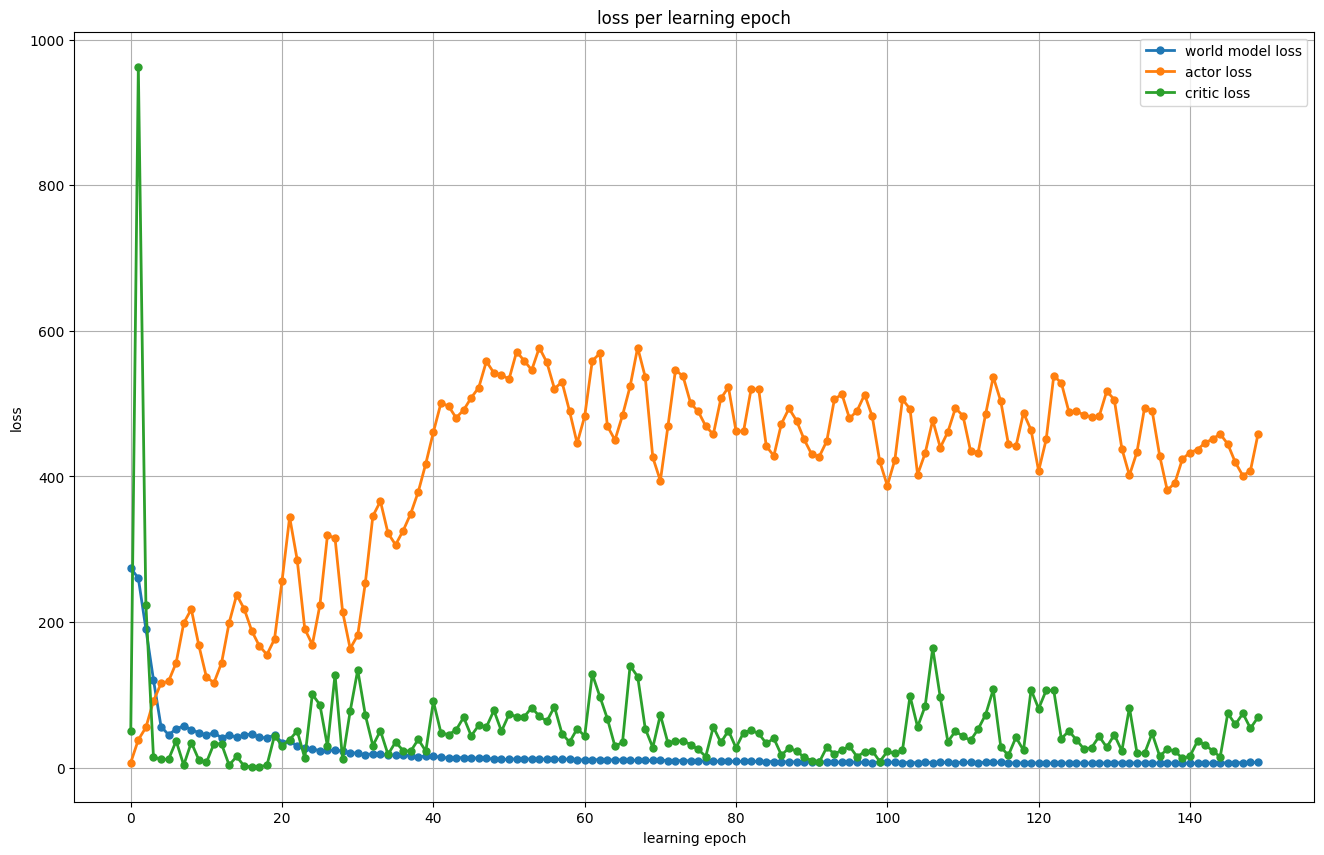

In [ ]:
# 学習結果(損失値)の推移をグラフ化
graph_loss_x_data_array = np.arange(stop=LEARNING_EPOCH)
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(graph_loss_x_data_array,
         my_world_model_average_loss_list,
         label="world model loss",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(graph_loss_x_data_array,
         my_actor_average_loss_list,
         label="actor loss",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(graph_loss_x_data_array,
         my_critic_average_loss_list,
         label="critic loss",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.legend(loc=0)
ax1.set_title(label="loss per learning epoch")
ax1.set_xlabel(xlabel="learning epoch")
ax1.set_ylabel(ylabel="loss")
# ax1.set_xticks(ticks=graph_loss_x_data_array+1)
ax1.grid(True)
plt.show()

### メイン処理(推論)

In [ ]:
my_world_model.eval()
my_actor.eval()
my_critic.eval()
inventory_list = []
available_inventory_list = []
total_reward = 0
state_list, predicted_action_list, reward_list = inference_timestep(env=my_env,
                                                                    world_model=my_world_model,
                                                                    actor=my_actor)
for i in range(len(state_list)):
    inventory_list.append(state_list[i][0].item())
    available_inventory_list.append(state_list[i][0].item()+state_list[i][1].item()+state_list[i][2].item())
    total_reward = total_reward + reward_list[i].item()
print(total_reward)

-1.100000023841858


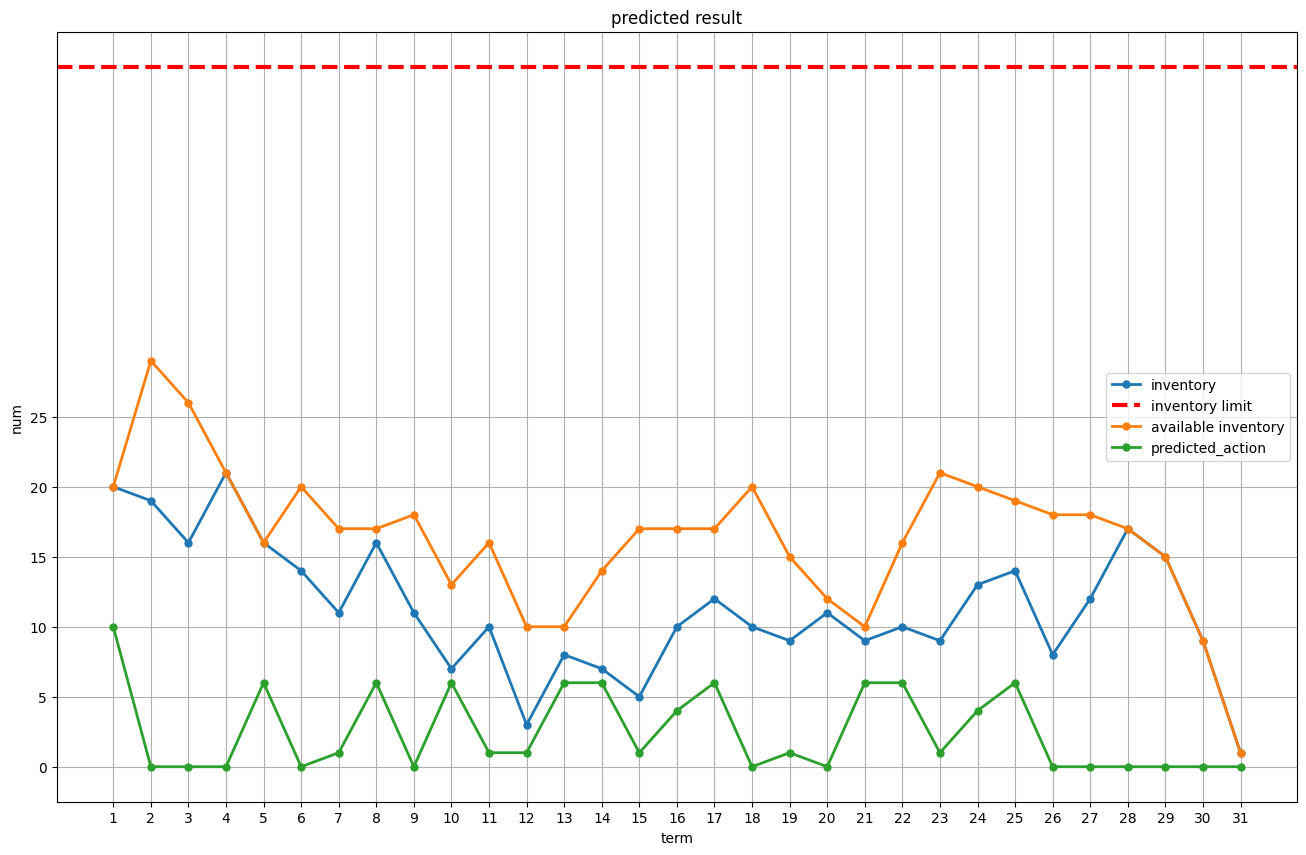

In [ ]:
predicted_result_x_data_array = np.arange(stop=len(state_list))+1  # x軸の値を0からでなく1からの方が分かりやすそうなので+1してる
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(predicted_result_x_data_array,
         inventory_list,
         label="inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.axhline(y=50,
            label="inventory limit",
            color="red",
            linestyle="dashed",
            linewidth=3)
ax1.plot(predicted_result_x_data_array,
         available_inventory_list,
         label="available inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(predicted_result_x_data_array,
         predicted_action_list,
         label="predicted_action",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.legend(loc=0)
ax1.set_title(label="predicted result")
ax1.set_xlabel(xlabel="term")
ax1.set_ylabel(ylabel="num")
ax1.set_xticks(ticks=predicted_result_x_data_array)
ax1.set_yticks(ticks=np.arange(start=0, stop=max(available_inventory_list), step=5))
ax1.grid(True)
plt.show()